# Loading libraries

In [360]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf, month_plot, quarter_plot
import joblib


In [361]:
sns.set_theme(palette='Set1',style='ticks' , context='notebook')

# Loading dataset

In [362]:
df= pd.read_csv(r"C:\Users\MINE\Desktop\Air passenger prediction\dataset\AirPassengers.csv")

In [363]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [364]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [365]:
# Setting and sorting index
df.set_index('Month', inplace=True)
df.index= pd.to_datetime(df.index)
df.sort_index(inplace=True)

In [366]:
df.index.dtype

dtype('<M8[ns]')

In [367]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [368]:
# Setting frequency and checking for null and duplicates
df=df.asfreq('MS')

In [369]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [370]:
df.shape

(144, 1)

In [371]:
df.isnull().sum()

#Passengers    0
dtype: int64

In [372]:
df.duplicated().sum()

26

In [373]:
df.drop_duplicates(keep='first', inplace=True)

# Exploratory Data Analysis

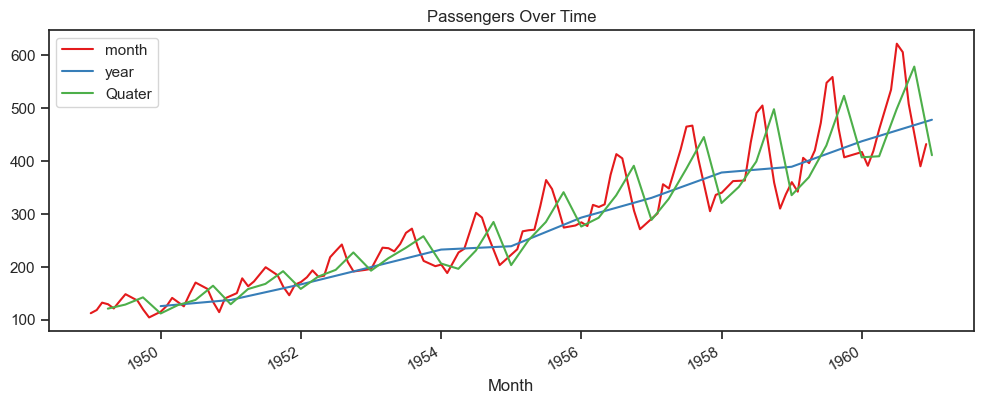

In [374]:
plt.figure(figsize=(10,4))
df['#Passengers'].plot(label='month')
df['#Passengers'].resample('YE').mean().plot(label='year')
df['#Passengers'].resample('QE').mean().plot(label='Quater')


plt.tight_layout()
plt.legend(loc='best')
plt.title('Passengers Over Time')
plt.show()

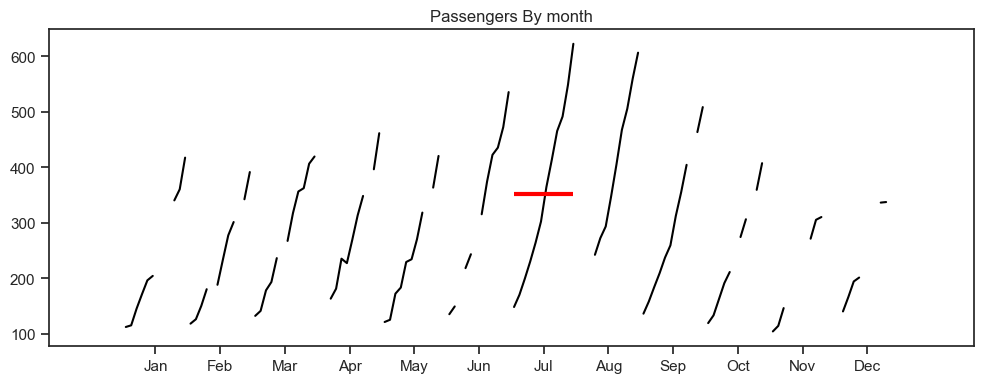

In [375]:

month_plot(df['#Passengers'].resample('ME').mean()).set_size_inches(10,4)

plt.title('Passengers By month')
plt.tight_layout()
plt.show()

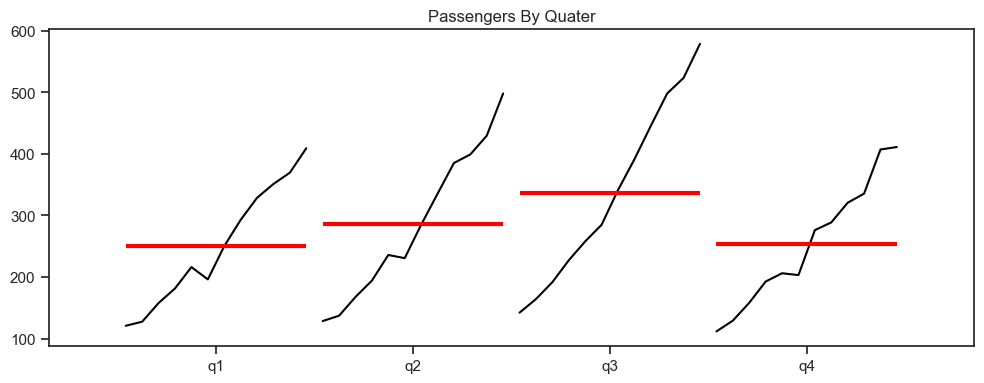

In [376]:
quarter_plot(df['#Passengers'].resample('QE').mean()).set_size_inches(10,4)

plt.title('Passengers By Quater')
plt.tight_layout()
plt.show()

In [377]:
decompose= seasonal_decompose(df['#Passengers'], model='mul',period=12)

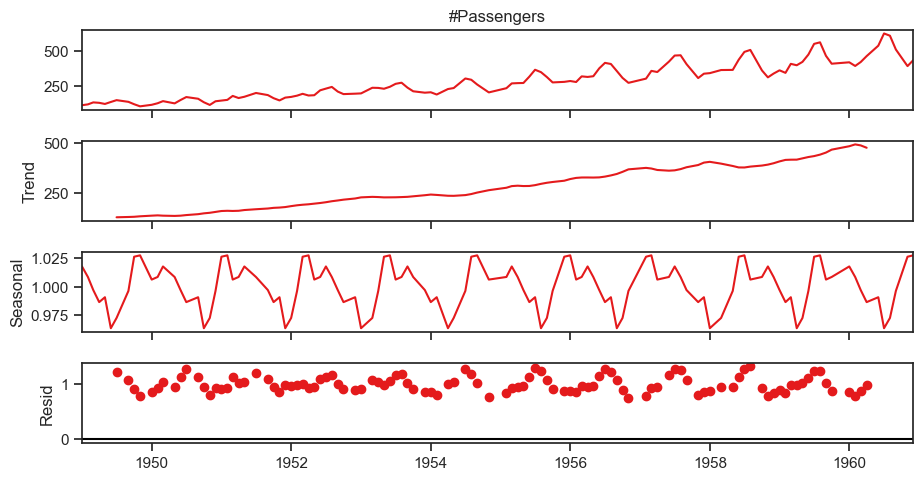

In [378]:

decompose.plot().set_size_inches(10,5)

plt.show()

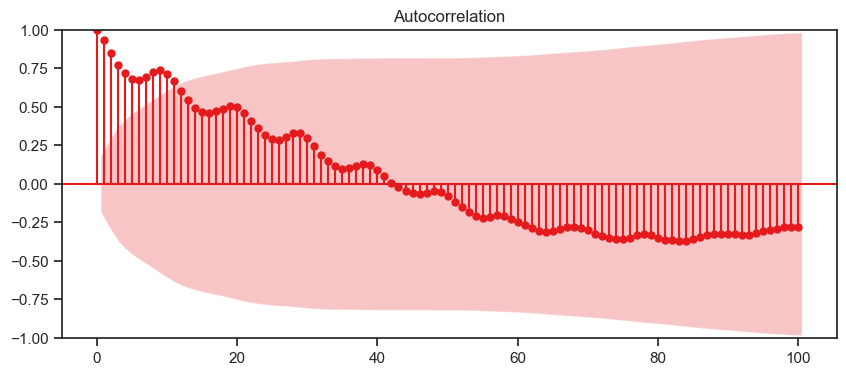

In [379]:
plot_acf(df['#Passengers'], lags=100).set_size_inches(10,4)

plt.show()

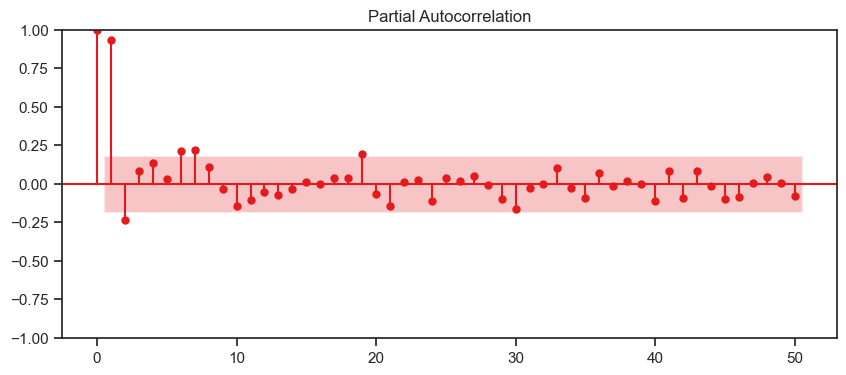

In [380]:
plot_pacf(df['#Passengers'], lags=50).set_size_inches(10,4)

plt.show()

In [381]:
# Performing feature engineering to add more features

def feature_engineering(data):
  data['month']= data.index.month
  data['quater']= data.index.quarter

  for i in [1,2,3,6,12]:
    data[f'lag{i}']= data['#Passengers'].shift(i)
  for i in [3,6,12]:
    data[f'rolling_mean{i}']= data['#Passengers'].rolling(window= i).mean()
    data[f'rolling_std{i}']= data['#Passengers'].rolling(window= i).std()
  return data


In [382]:
df= feature_engineering(df)

In [383]:
df.sample(5)

,#Passengers,month,quater,lag1,lag2,lag3,lag6,lag12,rolling_mean3,rolling_std3,rolling_mean6,rolling_std6,rolling_mean12,rolling_std12
Month,,,,,,,,,,,,,,
1949-04-01,129,4,2,132.0,118.0,112.0,NaN,NaN,126.333333,7.371115,NaN,NaN,NaN,NaN
1949-11-01,104,11,4,119.0,136.0,148.0,129.0,NaN,119.666667,16.010413,127.166667,15.587388,NaN,NaN
1955-06-01,315,6,2,270.0,269.0,267.0,259.0,204.0,284.666667,26.274195,259.500000,38.030251,255.000000,39.005827
1957-12-01,336,12,4,305.0,404.0,467.0,348.0,405.0,348.333333,50.639247,399.833333,66.835370,361.333333,64.903191
1960-08-01,606,8,3,622.0,535.0,461.0,417.0,420.0,587.666667,46.306947,505.666667,97.072482,491.666667,79.744288


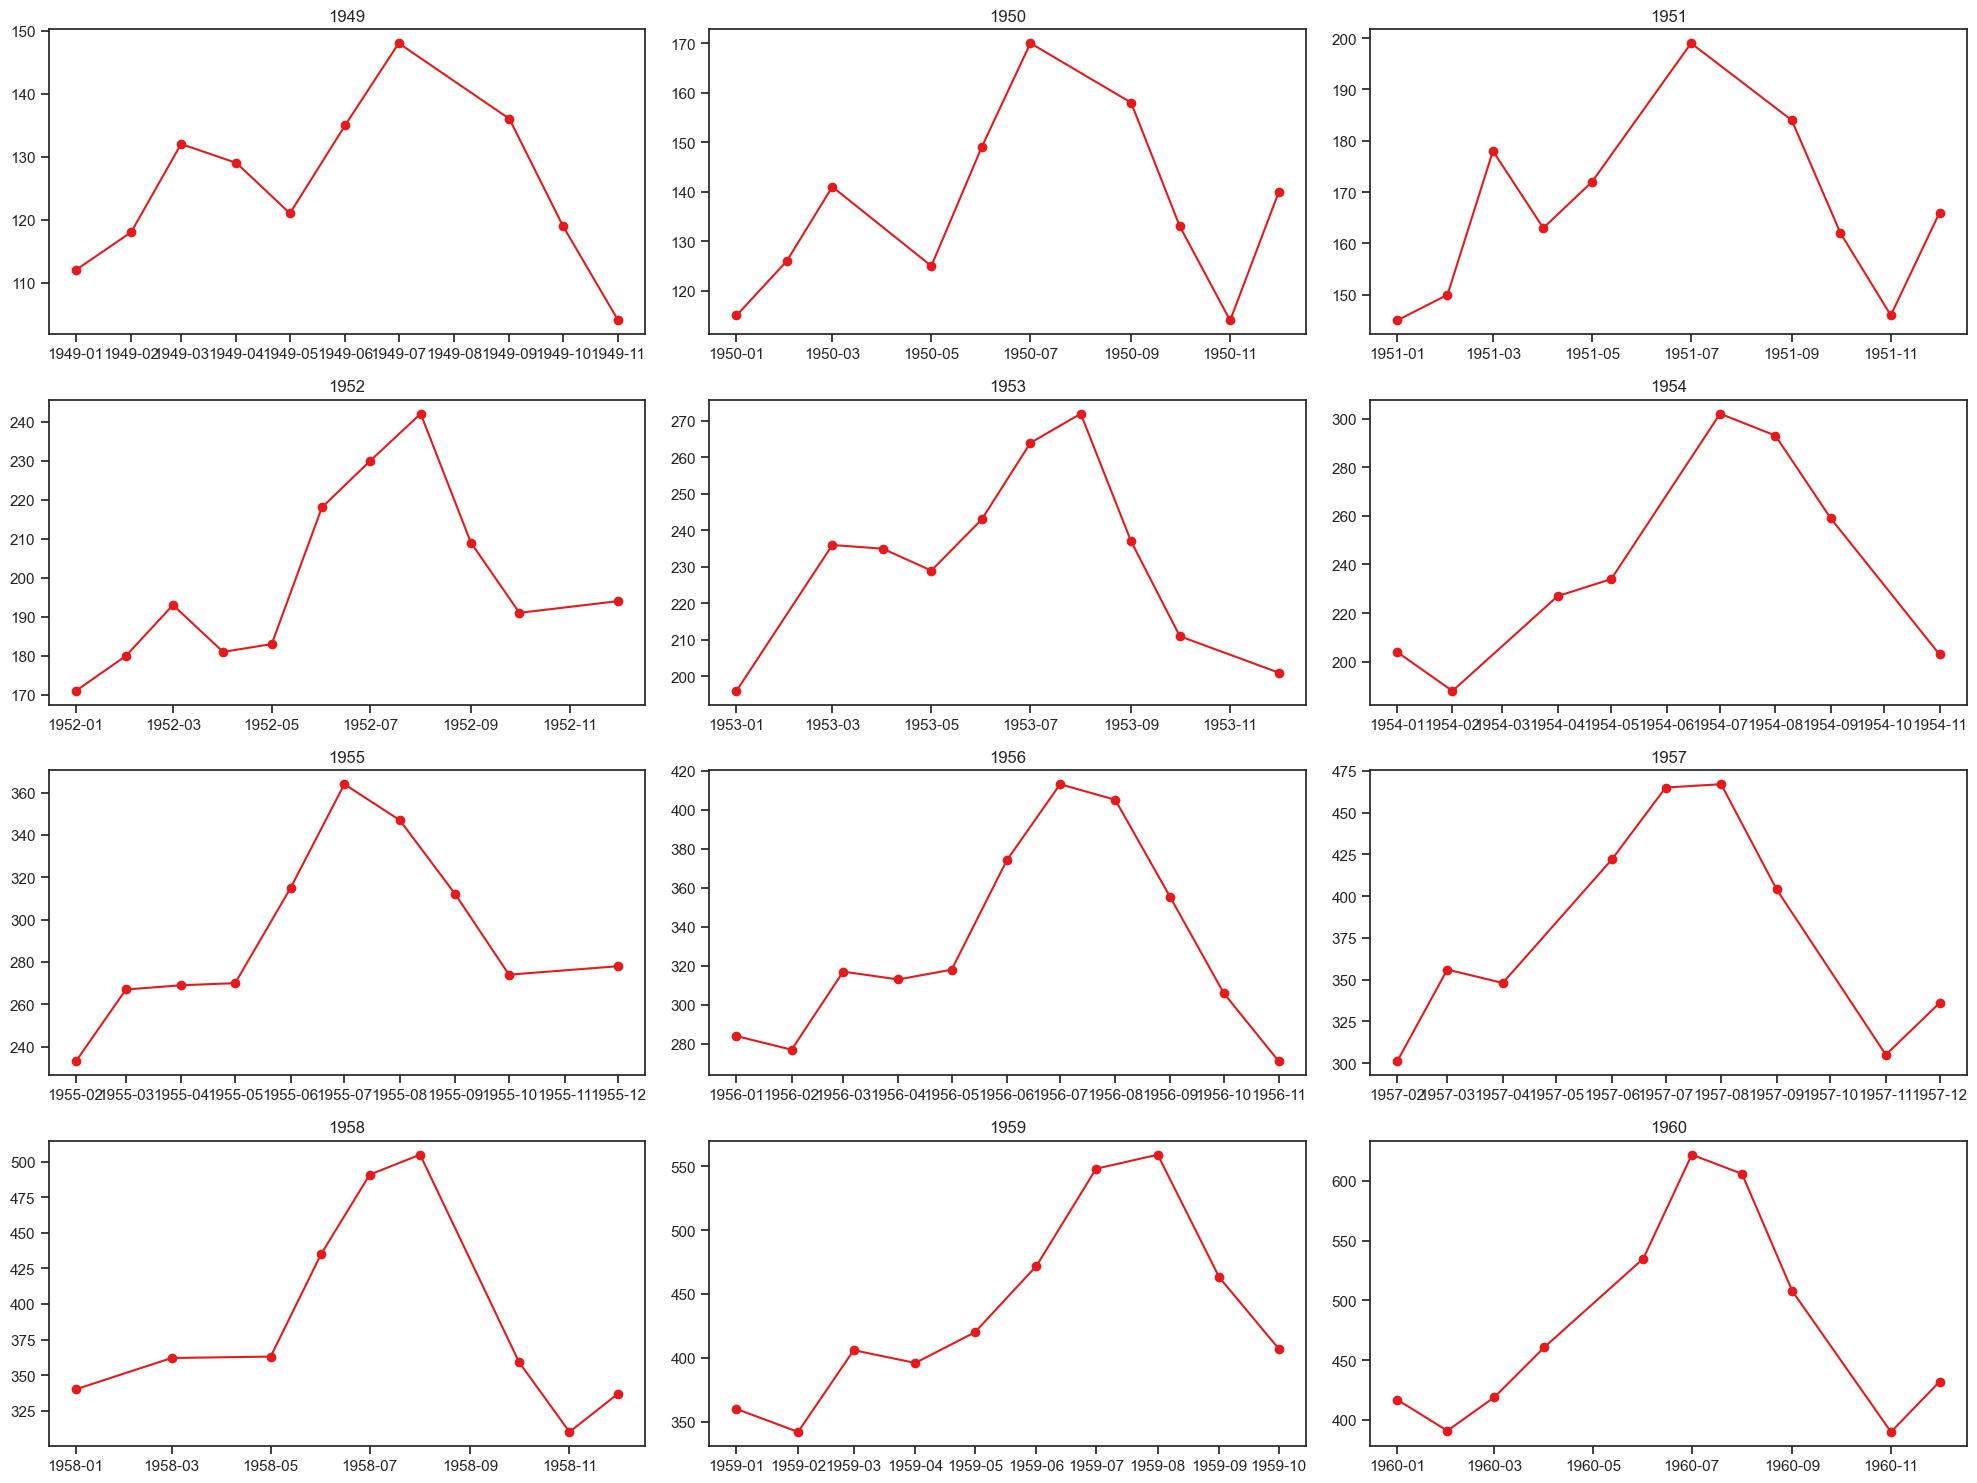

In [384]:
fig, axes= plt.subplots(4,3, figsize=(20,15))
axes= axes.reshape(-1)

for i,year in enumerate(['1949','1950','1951','1952','1953','1954','1955','1956','1957','1958','1959','1960']):
  axes[i].plot(df['#Passengers'].loc[year], marker='o')
  axes[i].set_title(year)

plt.tight_layout()
plt.show()

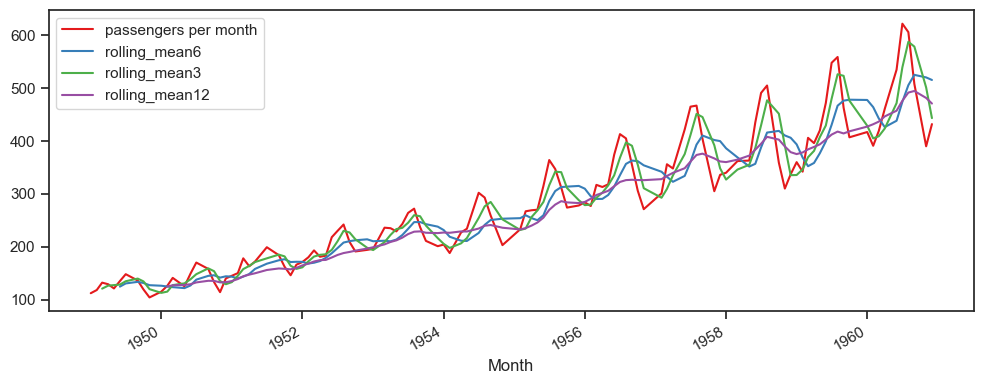

In [385]:
plt.figure(figsize=(10,4))
df['#Passengers'].plot(label='passengers per month')
df['rolling_mean6'].plot(legend=True)
df['rolling_mean3'].plot(legend=True)
df['rolling_mean12'].plot(legend=True)


plt.tight_layout()
plt.legend(loc='best')
plt.show()

In [399]:
train= df.iloc[:-12,:]
test= df.iloc[-12:,:]

In [396]:
joblib.dump(df,r'C:\Users\MINE\Desktop\Air passenger prediction\dataset\df.pkl')

['C:\\Users\\MINE\\Desktop\\Air passenger prediction\\dataset\\df.pkl']